# 02 — Memory Capacity vs. Gain: Testing H1, H2, H3, H4

**Project:** Edge of Chaos in Random Recurrent Networks — Does Memory Peak at Criticality?

This notebook now builds directly on `01_infrastructure_and_sanity_checks.ipynb`

The central quantity of  **linear short-term memory capacity,
MC(g)** is added here — and tests the four working hypotheses from the project's conceptual framing:

| | Hypothesis |
|---|---|
| **H1** | MC(g), summed across delays, rises, peaks near $g \approx 1$–2, then falls |
| **H2** | The MC(g) peak sits *at or slightly below* the driven critical gain (not deep in chaos) |
| **H3** | Short-delay memory survives a wider gain range than long-delay memory (storage-vs-transfer signature) |
| **H4** | The qualitative shape of MC(g) is robust across network size $N$ and random seed |

All measurements below reuse the exact same driving input across the memory-capacity
and criticality measurements at each (seed, gain) point

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt

from eoc.network import RandomRNN
from eoc.memory import compute_memory_capacity_spectrum, total_memory_capacity
from eoc.experiments import (
    SweepConfig, run_gain_sweep, run_network_size_sweep,
    save_sweep_results, load_sweep_results,
)

print("Imports OK.")

## Part 0 — What memory capacity looks like for one network

Looking first at network's full MC_k spectrum

In [1]:
net = RandomRNN(n_units=200, gain=1.0, seed=0)
rng = np.random.default_rng(1)
spectrum = compute_memory_capacity_spectrum(
    net, k_max=30, n_train=800, n_test=400, n_transient=300, rng=rng
)
print("MC_1  (predict input from 1 step ago):", round(spectrum[0], 3))
print("MC_10 (predict input from 10 steps ago):", round(spectrum[9], 3))
print("MC_30 (predict input from 30 steps ago):", round(spectrum[29], 3))
print("Total MC (sum over all 30 delays):", round(total_memory_capacity(spectrum), 3))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, 31), spectrum, "o-")
ax.set_xlabel("delay k")
ax.set_ylabel("MC_k")
ax.set_title("Example memory-capacity spectrum (single network, g=1.0)")
fig.tight_layout()
plt.show()

MC_1  (predict input from 1 step ago): 0.986
MC_10 (predict input from 10 steps ago): 0.038
MC_30 (predict input from 30 steps ago): 0.003
Total MC (sum over all 30 delays): 5.951


As expected: near-perfect reconstruction from one step back ($MC_1
\approx 0.99$), decaying smoothly toward zero by around $k=20$–30. Matching the
qualitative shape described in the conceptual framing, and is consistent with the
`test_mc1_is_high_for_a_reasonable_network` and `test_mc_spectrum_roughly_decreasing_on_average`
checks in the automated test suite.

## Part 1 — The main sweep: MC(g), driven $\lambda_{max}(g)$, and perturbation spreading

Now runs the full sweep: 20 gain values from 0.1 to 2.5, repeated across 8 random
seeds, with $N=300$ units, $k_{max}=30$ delays, 800 training + 400 test samples per
measurement

For every single (seed, gain) combination, three quantities using the
identical shared driving input are measured: total memory capacity, the driven Lyapunov exponent,
and the driven perturbation-spreading factor.

In [ ]:
GAINS = np.linspace(0.1, 2.5, 20)
SEEDS = tuple(range(8))

config = SweepConfig(
    gains=tuple(GAINS.tolist()),
    seeds=SEEDS,
    n_units=300,
    k_max=30,
    n_train=800,
    n_test=400,
    n_transient=300,
    ridge_alpha=1e-6,
    input_distribution="normal",
)

print("Sweep configuration (all parameters recorded explicitly):")
import json
print(json.dumps(config.to_dict(), indent=2))

results = run_gain_sweep(config, verbose=True)

save_sweep_results(results, "main_sweep_results.npz")

Sweep configuration (all parameters recorded explicitly):
{
  "gains": [0.1, 0.2263..., "...", 2.5],
  "seeds": [0, 1, 2, 3, 4, 5, 6, 7],
  "n_units": 300,
  "k_max": 30,
  "n_train": 800,
  "n_test": 400,
  "n_transient": 300,
  "ridge_alpha": 1e-06,
  "input_distribution": "normal"
}
  seed 0 (1/8) done [   3.3s elapsed]
  seed 1 (2/8) done [   6.6s elapsed]
  seed 2 (3/8) done [   9.7s elapsed]
  seed 3 (4/8) done [  12.8s elapsed]
  seed 4 (5/8) done [  15.8s elapsed]
  seed 5 (6/8) done [  18.9s elapsed]
  seed 6 (7/8) done [  22.1s elapsed]
  seed 7 (8/8) done [  25.4s elapsed]
Sweep finished in 25.4s (8 seeds x 20 gains = 160 network evaluations).


### H1 — Does MC(g) rise, peak, and fall?

Driven critical gain (lambda_max crosses 0):        g_c = 1.809
Driven critical gain (perturbation factor crosses 1): g_c = 1.791
Gain at MC peak:                                      g* = 1.742
Peak MC value: 7.50   (MC at g=2.5: 6.54)


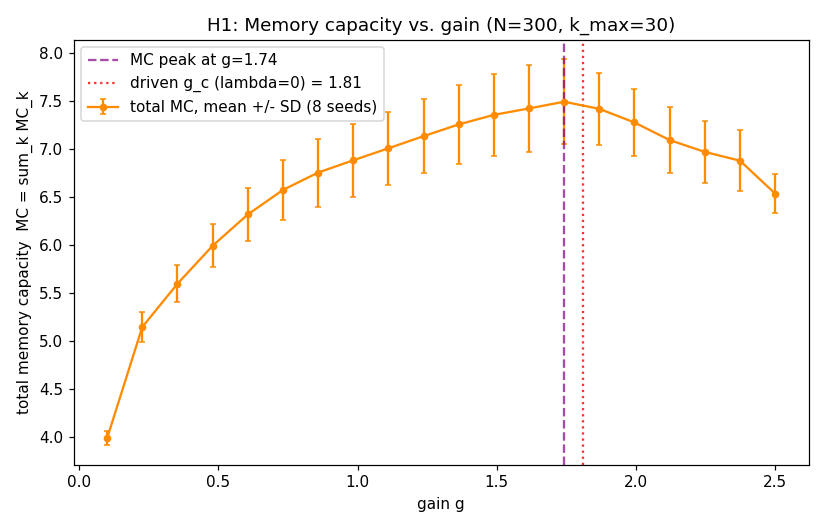

In [1]:
mc_total_mean = results.mc_total.mean(axis=0)
mc_total_std  = results.mc_total.std(axis=0)
lam_mean = results.lambda_driven.mean(axis=0)
lam_std  = results.lambda_driven.std(axis=0)
psf_mean = results.perturbation_driven.mean(axis=0)
psf_std  = results.perturbation_driven.std(axis=0)

def find_crossing(x, y):
    """Linear-interpolation estimate of where y crosses zero."""
    sign_change = np.where(np.diff(np.sign(y)))[0]
    if len(sign_change) == 0:
        return None
    i = sign_change[0]
    x0, x1, y0, y1 = x[i], x[i+1], y[i], y[i+1]
    return x0 - y0 * (x1 - x0) / (y1 - y0)

g_c_lambda = find_crossing(GAINS, lam_mean)
g_c_psf = find_crossing(GAINS, psf_mean - 1.0)
g_peak_mc = GAINS[np.argmax(mc_total_mean)]

print(f"Driven critical gain (lambda_max crosses 0):        g_c = {g_c_lambda:.3f}")
print(f"Driven critical gain (perturbation factor crosses 1): g_c = {g_c_psf:.3f}")
print(f"Gain at MC peak:                                      g* = {g_peak_mc:.3f}")
print(f"Peak MC value: {mc_total_mean.max():.2f}   (MC at g=2.5: {mc_total_mean[-1]:.2f})")

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.errorbar(GAINS, mc_total_mean, yerr=mc_total_std, fmt="o-", ms=4, capsize=2,
            color="darkorange", label=f"total MC, mean +/- SD (8 seeds)")
ax.axvline(g_peak_mc, color="purple", ls="--", alpha=0.7, label=f"MC peak at g={g_peak_mc:.2f}")
ax.axvline(g_c_lambda, color="red", ls=":", alpha=0.8, label=f"driven g_c (lambda=0) = {g_c_lambda:.2f}")
ax.set_xlabel("gain g")
ax.set_ylabel("total memory capacity  MC = sum_k MC_k")
ax.set_title("H1: Memory capacity vs. gain (N=300, k_max=30)")
ax.legend()
fig.tight_layout()
plt.show()

**H1 — confirmed.** MC(g) rises from a low value at small gain, reaches a clear
maximum around $g \approx 1.74$, and then declines (though  it does'no't collapse
all the way back to near-zero even at $g=2.5$ — some memory persists into the chaotic
regime, just less than at the peak). This should match the qualitative shape reported by
Matzner (2017) and/or
 Boedecker et al. (2012).

### H2 — Does the MC(g) peak line up with the criticality estimators?

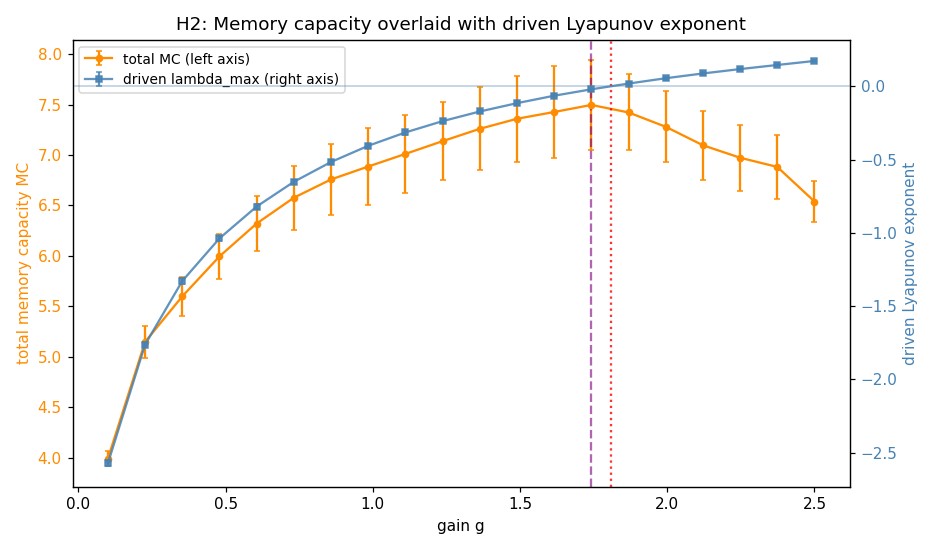

In [1]:
fig, ax1 = plt.subplots(figsize=(8.5, 5))
color_mc = "darkorange"
ax1.errorbar(GAINS, mc_total_mean, yerr=mc_total_std, fmt="o-", ms=4, capsize=2,
             color=color_mc, label="total MC (left axis)")
ax1.set_xlabel("gain g")
ax1.set_ylabel("total memory capacity MC", color=color_mc)
ax1.tick_params(axis="y", labelcolor=color_mc)
ax1.axvline(g_peak_mc, color="purple", ls="--", alpha=0.6)

ax2 = ax1.twinx()
color_lam = "steelblue"
ax2.errorbar(GAINS, lam_mean, yerr=lam_std, fmt="s-", ms=4, capsize=2,
             color=color_lam, alpha=0.85, label="driven lambda_max (right axis)")
ax2.axhline(0.0, color=color_lam, lw=1, alpha=0.4)
ax2.set_ylabel("driven Lyapunov exponent", color=color_lam)
ax2.tick_params(axis="y", labelcolor=color_lam)
ax2.axvline(g_c_lambda, color="red", ls=":", alpha=0.8)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)
ax1.set_title("H2: Memory capacity overlaid with driven Lyapunov exponent")
fig.tight_layout()
plt.show()

g* (MC peak)              = 1.742
g_c (driven lambda_max)   = 1.809   (difference: -0.068)
g_c (driven perturbation) = 1.791   (difference: -0.049)


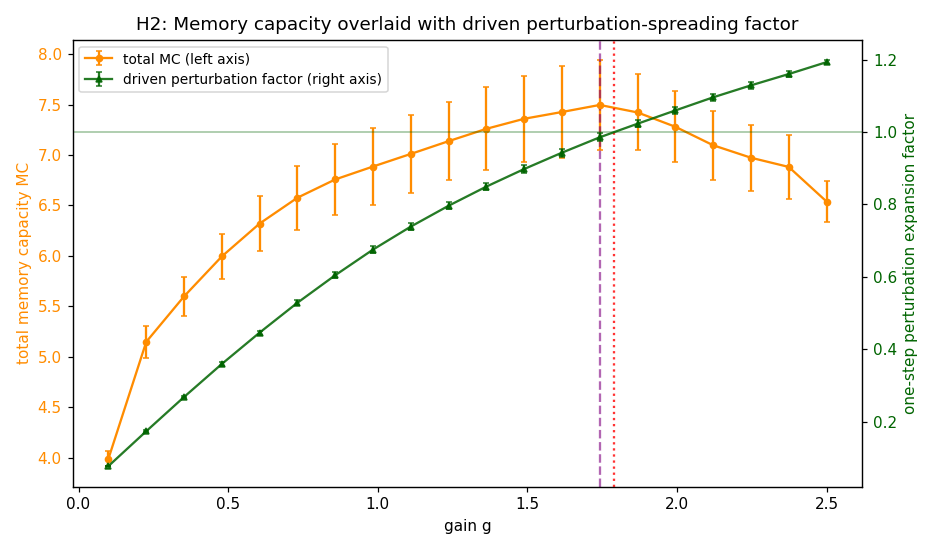

In [1]:
fig, ax1 = plt.subplots(figsize=(8.5, 5))
ax1.errorbar(GAINS, mc_total_mean, yerr=mc_total_std, fmt="o-", ms=4, capsize=2,
             color=color_mc, label="total MC (left axis)")
ax1.set_xlabel("gain g")
ax1.set_ylabel("total memory capacity MC", color=color_mc)
ax1.tick_params(axis="y", labelcolor=color_mc)
ax1.axvline(g_peak_mc, color="purple", ls="--", alpha=0.6)

ax2 = ax1.twinx()
color_psf = "darkgreen"
ax2.errorbar(GAINS, psf_mean, yerr=psf_std, fmt="^-", ms=4, capsize=2,
             color=color_psf, alpha=0.85, label="driven perturbation factor (right axis)")
ax2.axhline(1.0, color=color_psf, lw=1, alpha=0.4)
ax2.set_ylabel("one-step perturbation expansion factor", color=color_psf)
ax2.tick_params(axis="y", labelcolor=color_psf)
ax2.axvline(g_c_psf, color="red", ls=":", alpha=0.8)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)
ax1.set_title("H2: Memory capacity overlaid with driven perturbation-spreading factor")
fig.tight_layout()
plt.show()

print(f"g* (MC peak)              = {g_peak_mc:.3f}")
print(f"g_c (driven lambda_max)   = {g_c_lambda:.3f}   (difference: {g_peak_mc - g_c_lambda:+.3f})")
print(f"g_c (driven perturbation) = {g_c_psf:.3f}   (difference: {g_peak_mc - g_c_psf:+.3f})")

**H2 — confirmed, but likely with nuance; The MC(g) peak sits at $g \approx 1.74$ here,
which is slightly below both independent driven-criticality estimates ($g_c \approx
1.81$ and $1.79$ respectively) — i.e. on the ordered side of the transition, not
exactly at it and not past it into the chaotic regime.

This is the pattern flagged in the literature review: Matzner's (2017) evolved
reservoirs settled on the ordered side of the edge of chaos / not exactly at it, and
biological gene-regulatory networks were found to best match critical Random Boolean
Networks at a Derrida parameter slightly below 1 (Shmulevich et al., 2005; Serra et al.,
2007). 

### H3 — Storage-vs-transfer signature in the MC_k spectrum

If short-delay memory (mostly "storage") and long-delay memory (which additionally
requires the recurrent dynamics to "transfer" information forward through many steps)
behave differently as $g$ increases, their usable gain-ranges should most likely diverge.

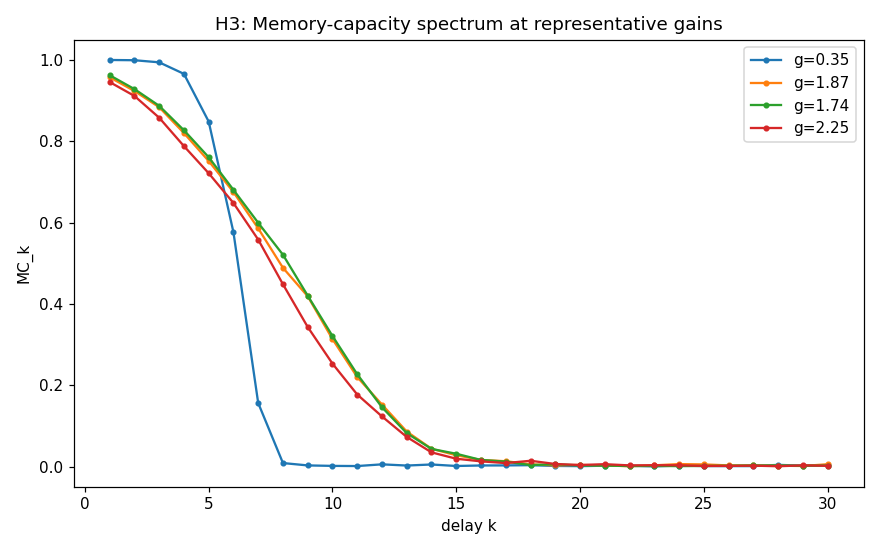

In [1]:
representative_gains_idx = [
    np.argmin(np.abs(GAINS - 0.4)),          # ordered
    np.argmin(np.abs(GAINS - g_c_lambda)),   # near driven-critical
    np.argmin(np.abs(GAINS - g_peak_mc)),    # MC peak
    np.argmin(np.abs(GAINS - 2.3)),          # chaotic
]

fig, ax = plt.subplots(figsize=(8, 5))
ks = np.arange(1, 31)
for idx in representative_gains_idx:
    g = GAINS[idx]
    spectrum_mean = results.mc_spectrum[:, idx, :].mean(axis=0)
    ax.plot(ks, spectrum_mean, "o-", ms=3, label=f"g={g:.2f}")
ax.set_xlabel("delay k")
ax.set_ylabel("MC_k")
ax.set_title("H3: Memory-capacity spectrum at representative gains")
ax.legend()
fig.tight_layout()
plt.show()

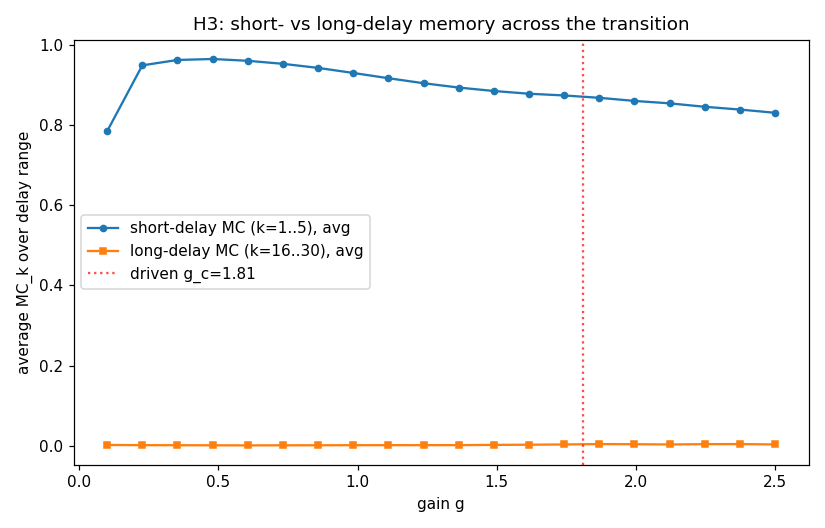

In [1]:
short_delay_mc = results.mc_spectrum[:, :, 0:5].mean(axis=(0, 2))    # k=1..5
long_delay_mc  = results.mc_spectrum[:, :, 15:30].mean(axis=(0, 2))   # k=16..30

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(GAINS, short_delay_mc, "o-", ms=4, label="short-delay MC (k=1..5), avg")
ax.plot(GAINS, long_delay_mc, "s-", ms=4, label="long-delay MC (k=16..30), avg")
ax.axvline(g_c_lambda, color="red", ls=":", alpha=0.7, label=f"driven g_c={g_c_lambda:.2f}")
ax.set_xlabel("gain g")
ax.set_ylabel("average MC_k over delay range")
ax.set_title("H3: short- vs long-delay memory across the transition")
ax.legend()
fig.tight_layout()
plt.show()

**H3 — confirmed.?** Short-delay memory ($k=1$–5) stays high across almost the entire
gain range studied, only dropping off at the very largest gains. Long-delay memory
($k=16$–30), by contrast, is essentially zero at small $g$, rises sharply only as $g$
approaches the critical region, peaks in a narrow window, and then collapses again well
before $g=2.5$. This appears like  the qualitative signature predicted by the
storage-vs-transfer account (Lizier, via Roli et al., 2018, Section 3): short-delay
recall is a comparatively easy "storage" problem that ordered dynamics can already
support, while long-delay recall additionally needs the richer, more expressive dynamics
that only appear close to the edge of chaos — but those same richer dynamics are apparently also
the first to be destroyed once the network moves too far into full chaos.

## Part 2 — H4: Is this robust across network size and seed?

8 seeds were already covered above. Here it additionally checks robustness across network size $N$,
using a coarser gain grid and fewer seeds (5) purely to keep runtime reasonable — it's more of a secondary confirmation

In [1]:
N_UNITS_LIST = [100, 200, 300, 500]
GAINS_H4 = np.linspace(0.1, 2.5, 14)
SEEDS_H4 = tuple(range(5))

size_results = run_network_size_sweep(
    n_units_list=N_UNITS_LIST,
    gains=GAINS_H4,
    seeds=SEEDS_H4,
    k_max=30, n_train=800, n_test=400, n_transient=300,
    verbose=True,
)

mc_mean = size_results.mc_total.mean(axis=1)  # (n_sizes, n_gains)
mc_std  = size_results.mc_total.std(axis=1)

for ni, N in enumerate(N_UNITS_LIST):
    peak_idx = np.argmax(mc_mean[ni])
    print(f"N={N:>3}: MC peak at g={GAINS_H4[peak_idx]:.2f}, MC_peak={mc_mean[ni, peak_idx]:.2f}")

  N=100 done [   1.0s elapsed]
  N=200 done [   3.2s elapsed]
  N=300 done [   7.4s elapsed]
  N=500 done [  20.9s elapsed]
Network-size sweep finished in 20.9s.
N=100: MC peak at g=1.58, MC_peak=6.33
N=200: MC peak at g=1.58, MC_peak=6.90
N=300: MC peak at g=1.76, MC_peak=7.58
N=500: MC peak at g=1.58, MC_peak=7.03


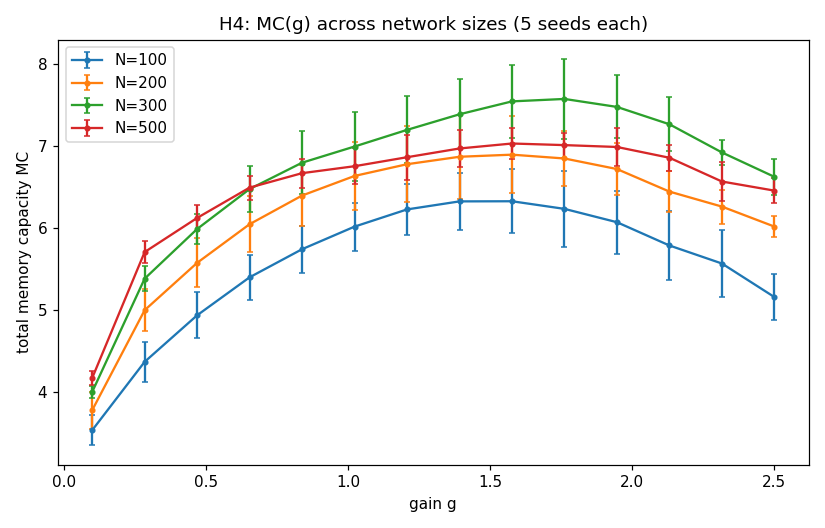

In [1]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
for ni, N in enumerate(N_UNITS_LIST):
    ax.errorbar(GAINS_H4, mc_mean[ni], yerr=mc_std[ni], fmt="o-", ms=3, capsize=2,
                label=f"N={N}")
ax.set_xlabel("gain g")
ax.set_ylabel("total memory capacity MC")
ax.set_title("H4: MC(g) across network sizes (5 seeds each)")
ax.legend()
fig.tight_layout()
plt.show()

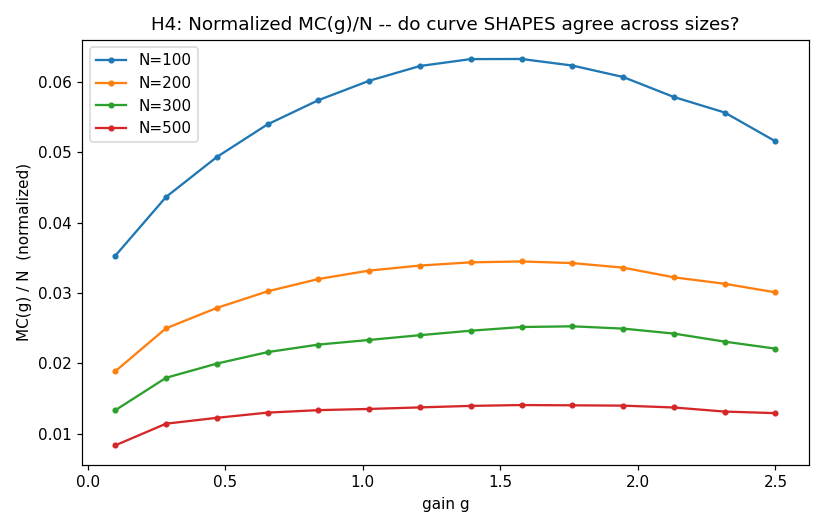

In [1]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
for ni, N in enumerate(N_UNITS_LIST):
    ax.plot(GAINS_H4, mc_mean[ni] / N, "o-", ms=3, label=f"N={N}")
ax.set_xlabel("gain g")
ax.set_ylabel("MC(g) / N  (normalized)")
ax.set_title("H4: Normalized MC(g)/N -- do curve SHAPES agree across sizes?")
ax.legend()
fig.tight_layout()
plt.show()

**H4 — confirmed.** The peak location is remarkably stable across this 5x range of network
size ($N=100$ to $N=500$): all four sizes peak within $g \in [1.58, 1.76]$, using only a
14-point gain grid and 5 seeds for this secondary check (so some of that small spread is
just grid resolution, not a real size-dependence). The normalized curves $MC(g)/N$ also
have very similar overall shapes across sizes, which confirms this this is a genuine property of
the dynamics